# 02 — Market Profiles

## How can the same simulation engine create very different commercial markets?

In Notebook 01, we generated our first HealthSynth market and explored the resulting datasets.

Now we will look at one of the most important ideas behind HealthSynth: **market profiles**.

A profile is a YAML configuration file that describes the commercial world before the simulation begins. It can define:

- the market and country
- the HCP population
- the product portfolio
- promotional channels
- product affinity
- demand assumptions
- simulation duration
- commercial events

The Python engine remains unchanged. The configuration changes the world being simulated.

In this notebook, we will compare two profiles:

- a general Canada profile
- an oncology-focused training profile

By the end, you will understand how configuration choices flow through to the generated datasets.

## The Guiding Idea

HealthSynth separates **simulation logic** from **commercial configuration**.

```text
HealthSynth Engine
        +
Market Profile
        =
Simulated Commercial World
```

This allows the same code to generate different environments without rewriting the generators.

For example:

```text
Canada Profile
    → broad specialty mix
    → general commercial environment

Oncology Training Profile
    → oncology-focused HCP population
    → oncology products
    → different activity and demand patterns
```

Profiles make HealthSynth useful as a learning sandbox. We can change assumptions, rerun the simulation, and observe how the resulting data changes.

## Import the Tools

We will use:

- `generate` to run the simulations
- `pandas` to compare outputs
- `matplotlib` to visualize the differences
- `yaml` to inspect the profile files themselves
- `Path` to work with file locations

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

from healthsynth.generator import generate

## Locate the Two Profiles

A profile is simply a readable YAML file stored in the repository.

We will compare:

```text
configs/profiles/canada.yaml
configs/profiles/oncology_training.yaml
```

In [2]:
canada_profile_path = Path(
    "../configs/profiles/canada.yaml"
)

oncology_profile_path = Path(
    "../configs/profiles/oncology_training.yaml"
)

print("Canada profile exists:", canada_profile_path.exists())
print("Oncology profile exists:", oncology_profile_path.exists())

Canada profile exists: True
Oncology profile exists: True


## Read the Profile Configuration

Before generating any data, let us inspect the YAML as a Python dictionary.

This helps us distinguish between:

- what was configured
- what was generated

In [3]:
with canada_profile_path.open(
    "r",
    encoding="utf-8",
) as file:
    canada_config = yaml.safe_load(file)

with oncology_profile_path.open(
    "r",
    encoding="utf-8",
) as file:
    oncology_config = yaml.safe_load(file)

In [4]:
sorted(canada_config.keys())

['channel_distribution',
 'channel_response_multiplier',
 'decile_distribution',
 'generation',
 'locale',
 'market',
 'num_territories',
 'products',
 'profile_name',
 'specialty_distribution',
 'specialty_product_affinity']

A profile may contain several sections. Typical examples include:

| Section | Purpose |
|---|---|
| `generation` | Size, timeline, seed, and output settings |
| `market` | Market identity and geography |
| `products` | Product portfolio and competitive assumptions |
| `specialty_distribution` | Expected HCP specialty mix |
| `channel_distribution` | Promotional channel mix |
| `specialty_product_affinity` | Relative fit between specialties and products |
| `market_demand` | Market volume, growth, and seasonality |

Not every profile must use every available field.

## Compare the Market Definitions

The market section provides the business identity of the simulation.

In [5]:
market_comparison = pd.DataFrame(
    [
        {
            "profile": "Canada",
            **canada_config.get("market", {}),
        },
        {
            "profile": "Oncology Training",
            **oncology_config.get("market", {}),
        },
    ]
)

market_comparison

,profile,market_id,market_name,country
0,Canada,MKT_CA,Canada Commercial,Canada
1,Oncology Training,MKT_ONC_CA,Oncology Training,Canada


## Compare the Generation Settings

Generation settings control the size and time horizon of the simulation.

These values can still be overridden when calling `generate()`.

In [6]:
generation_comparison = pd.DataFrame(
    [
        {
            "profile": "Canada",
            **canada_config.get("generation", {}),
        },
        {
            "profile": "Oncology Training",
            **oncology_config.get("generation", {}),
        },
    ]
)

generation_comparison

,profile,hcps,years,seed,output_format
0,Canada,1000,3,42,all
1,Oncology Training,1000,3,42,all


## Compare the Configured Products

Products are part of the commercial world, not merely labels added after generation.

Their configuration may describe:

- product identity
- manufacturer
- therapeutic area
- launch date
- brand type
- baseline market share
- scenario-specific commercial behaviour

In [7]:
def configured_products(
    profile_name: str,
    config: dict,
) -> pd.DataFrame:
    product_frame = pd.DataFrame(
        config.get("products", [])
    )

    product_frame.insert(
        0,
        "profile",
        profile_name,
    )

    return product_frame


configured_product_comparison = pd.concat(
    [
        configured_products(
            "Canada",
            canada_config,
        ),
        configured_products(
            "Oncology Training",
            oncology_config,
        ),
    ],
    ignore_index=True,
)

product_columns = [
    column
    for column in [
        "profile",
        "product_id",
        "product_name",
        "therapeutic_area",
        "manufacturer",
        "brand_type",
        "baseline_market_share",
        "launch_date",
    ]
    if column in configured_product_comparison.columns
]

configured_product_comparison[product_columns]

,profile,product_id,product_name,therapeutic_area,manufacturer,brand_type,baseline_market_share,launch_date
0,Canada,P001,CardioOne,Cardiology,NVA Pharma,Innovator,1.00,2023-01-01
1,Canada,P002,NeuroMax,Neurology,NVA Pharma,Innovator,1.00,2022-07-01
2,Canada,P003,EndoCare,Endocrinology,NVA Pharma,Innovator,1.00,2021-01-01
3,Oncology Training,P001,OncoNova,Oncology,NVA Pharma,Innovator,0.45,2023-01-01
4,Oncology Training,P002,Tumora,Oncology,Competitor A,Competitor,0.35,2022-07-01
5,Oncology Training,P003,Immunex,Oncology,Competitor B,Competitor,0.20,2021-01-01


### What to Notice

The profiles may differ in more than the number of products.

They can represent different:

- therapeutic areas
- manufacturers
- competitive positions
- launch histories
- market-share assumptions

These differences later influence market share, commercial activity, and prescription allocation.

## Compare the Configured Specialty Mix

The specialty distribution describes the expected composition of the HCP population.

A general market may contain a broad specialty mix. An oncology training profile should place greater emphasis on oncology specialists.

In [8]:
def distribution_frame(
    profile_name: str,
    distribution: dict,
    category_name: str,
) -> pd.DataFrame:
    return pd.DataFrame(
        {
            category_name: list(distribution.keys()),
            "configured_share": list(
                distribution.values()
            ),
            "profile": profile_name,
        }
    )


configured_specialties = pd.concat(
    [
        distribution_frame(
            "Canada",
            canada_config.get(
                "specialty_distribution",
                {},
            ),
            "specialty",
        ),
        distribution_frame(
            "Oncology Training",
            oncology_config.get(
                "specialty_distribution",
                {},
            ),
            "specialty",
        ),
    ],
    ignore_index=True,
)

configured_specialties

,specialty,configured_share,profile
0,Primary Care,0.35,Canada
1,Cardiology,0.20,Canada
2,Endocrinology,0.15,Canada
3,Oncology,0.10,Canada
4,Neurology,0.10,Canada
5,Pulmonology,0.10,Canada
6,Oncology,0.75,Oncology Training
7,Primary Care,0.10,Oncology Training
8,Cardiology,0.05,Oncology Training
9,Pulmonology,0.05,Oncology Training


In [9]:
specialty_pivot = configured_specialties.pivot(
    index="specialty",
    columns="profile",
    values="configured_share",
).fillna(0)

specialty_pivot

profile,Canada,Oncology Training
specialty,,
Cardiology,0.20,0.05
Endocrinology,0.15,0.02
Neurology,0.10,0.03
Oncology,0.10,0.75
Primary Care,0.35,0.10
Pulmonology,0.10,0.05


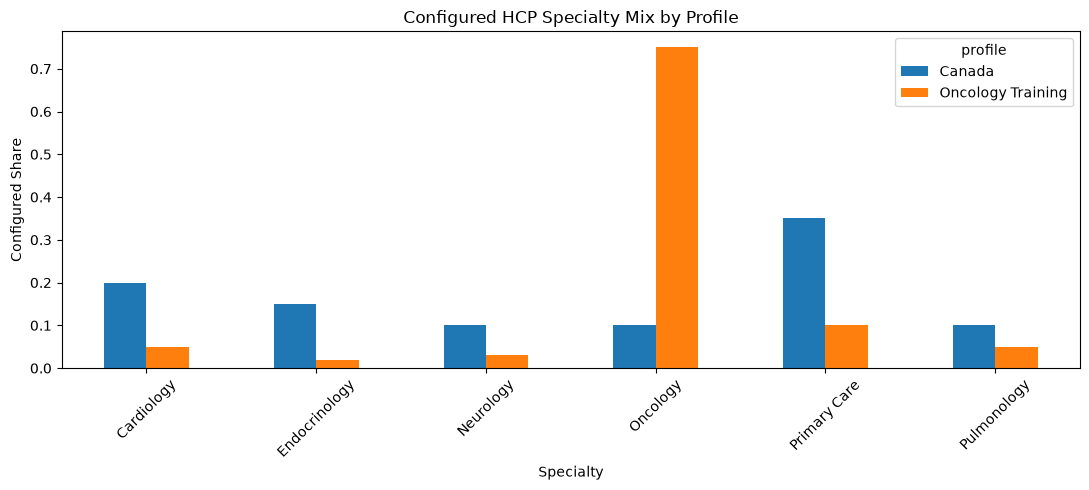

In [10]:
specialty_pivot.plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("Configured HCP Specialty Mix by Profile")
plt.xlabel("Specialty")
plt.ylabel("Configured Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The profile determines the intended customer population before any HCP records are generated.

This matters because specialty can influence:

- product relevance
- commercial targeting
- call activity
- prescription affinity
- downstream analytical results

The generated HCP mix should broadly reflect these configuration values, although exact counts may vary because the simulation uses random sampling.

## Compare the Configured Channel Mix

Promotional channels represent the ways in which a commercial organization interacts with HCPs.

Examples may include:

- representative calls
- email
- webinars
- digital advertising
- conferences

Different profiles can represent different engagement strategies.

In [11]:
configured_channels = pd.concat(
    [
        distribution_frame(
            "Canada",
            canada_config.get(
                "channel_distribution",
                {},
            ),
            "channel",
        ),
        distribution_frame(
            "Oncology Training",
            oncology_config.get(
                "channel_distribution",
                {},
            ),
            "channel",
        ),
    ],
    ignore_index=True,
)

channel_pivot = configured_channels.pivot(
    index="channel",
    columns="profile",
    values="configured_share",
).fillna(0)

channel_pivot

profile,Canada,Oncology Training
channel,,
Digital Ad,0.15,0.10
Email,0.25,0.15
Rep Call,0.45,0.65
Webinar,0.15,0.10


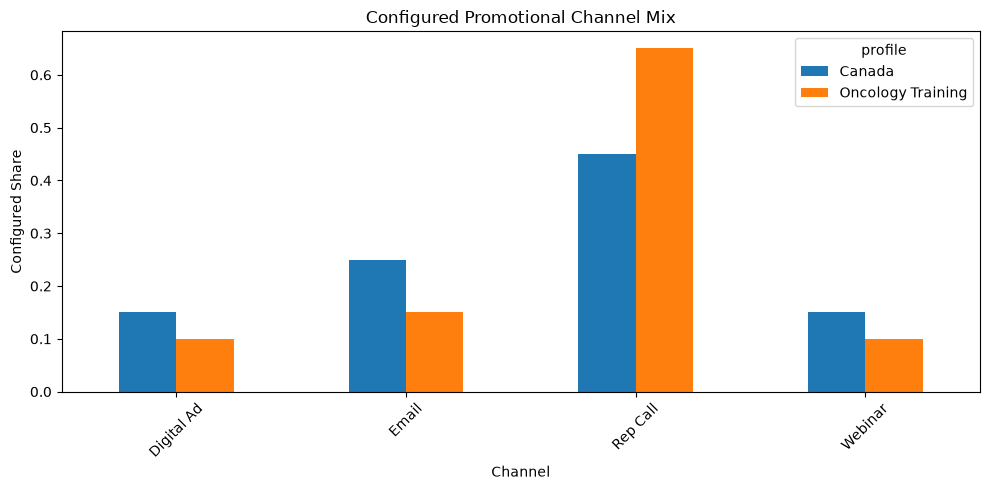

In [12]:
channel_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Configured Promotional Channel Mix")
plt.xlabel("Channel")
plt.ylabel("Configured Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Generate Both Markets

We will now run the same HealthSynth engine twice.

To make the comparison fair:

- both simulations will use 500 HCPs
- both will use the same random seed
- each will write to a separate output folder

The only major difference is the profile.

In [13]:
canada = generate(
    config_path=str(canada_profile_path),
    hcps=500,
    seed=42,
    output_dir="../output/profile_canada",
)

oncology = generate(
    config_path=str(oncology_profile_path),
    hcps=500,
    seed=42,
    output_dir="../output/profile_oncology",
)

## Compare the Generated Dataset Sizes

Some dataset sizes depend mainly on parameters such as HCP count and simulation duration.

Others may differ because of the profile's product portfolio and commercial assumptions.

In [14]:
def summarize_profile(
    name: str,
    datasets: dict,
) -> dict:
    return {
        "profile": name,
        "markets": len(datasets["market"]),
        "hcps": len(datasets["hcp_master"]),
        "products": len(datasets["product"]),
        "call_activity_rows": len(
            datasets["call_activity"]
        ),
        "market_share_rows": len(
            datasets["market_share"]
        ),
        "prescription_rows": len(
            datasets["prescriptions"]
        ),
    }


profile_summary = pd.DataFrame(
    [
        summarize_profile(
            "Canada",
            canada,
        ),
        summarize_profile(
            "Oncology Training",
            oncology,
        ),
    ]
)

profile_summary

,profile,markets,hcps,products,call_activity_rows,market_share_rows,prescription_rows
0,Canada,1,500,3,37208,108,54000
1,Oncology Training,1,500,3,37208,108,54000


### Dataset Size Is Not the Whole Story

Two simulations can contain a similar number of records while representing very different commercial worlds.

The more important questions are:

- Who are the customers?
- Which products compete?
- Which channels are used?
- How is demand distributed?
- What commercial behaviour emerges?

We will now compare some of those generated characteristics.

## Configured Mix Versus Generated HCP Population

The specialty distribution in YAML expresses an expected probability mix.

The HCP generator samples from that distribution to create individual records.

The generated result should therefore be close to the configured values, but not necessarily identical.

In [15]:
def generated_specialty_distribution(
    profile_name: str,
    datasets: dict,
) -> pd.DataFrame:
    result = (
        datasets["hcp_master"]["specialty"]
        .value_counts(normalize=True)
        .rename_axis("specialty")
        .reset_index(name="generated_share")
    )

    result["profile"] = profile_name

    return result


generated_specialties = pd.concat(
    [
        generated_specialty_distribution(
            "Canada",
            canada,
        ),
        generated_specialty_distribution(
            "Oncology Training",
            oncology,
        ),
    ],
    ignore_index=True,
)

generated_specialties

,specialty,generated_share,profile
0,Primary Care,0.378,Canada
1,Cardiology,0.182,Canada
2,Endocrinology,0.144,Canada
3,Pulmonology,0.108,Canada
4,Neurology,0.098,Canada
5,Oncology,0.090,Canada
6,Oncology,0.740,Oncology Training
7,Primary Care,0.106,Oncology Training
8,Cardiology,0.046,Oncology Training
9,Pulmonology,0.044,Oncology Training


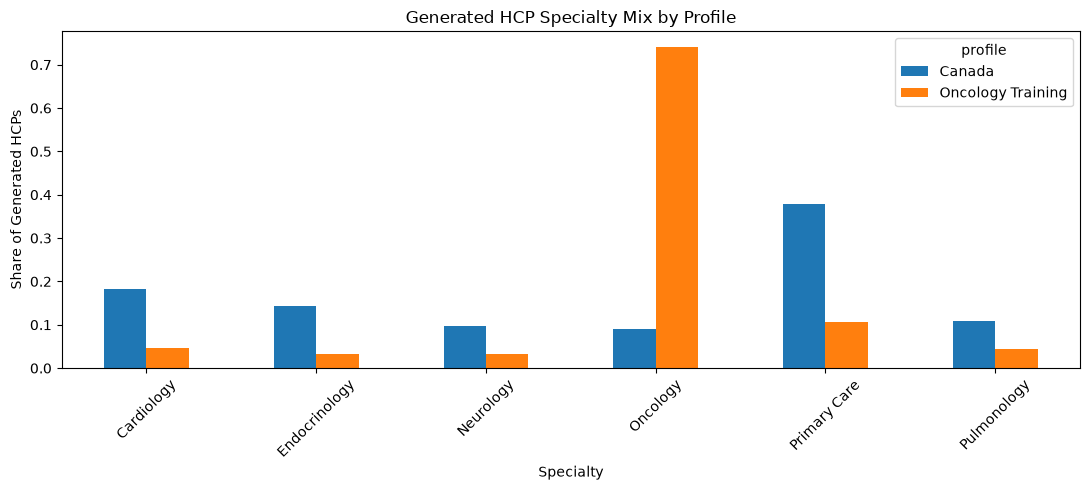

In [16]:
generated_specialty_pivot = (
    generated_specialties.pivot(
        index="specialty",
        columns="profile",
        values="generated_share",
    )
    .fillna(0)
)

generated_specialty_pivot.plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("Generated HCP Specialty Mix by Profile")
plt.xlabel("Specialty")
plt.ylabel("Share of Generated HCPs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What Changed?

The oncology profile should generate a customer population with a stronger concentration of oncology HCPs.

The Canada profile should reflect a broader commercial environment.

The same HCP generator produced both populations. The difference came from configuration.

## Validate the Oncology Specialty Assumption

Rather than relying only on the chart, we can calculate the oncology share directly.

In [17]:
oncology_hcp_share = (
    oncology["hcp_master"]["specialty"]
    .eq("Oncology")
    .mean()
)

canada_oncology_hcp_share = (
    canada["hcp_master"]["specialty"]
    .eq("Oncology")
    .mean()
)

pd.DataFrame(
    {
        "profile": [
            "Canada",
            "Oncology Training",
        ],
        "generated_oncology_hcp_share": [
            canada_oncology_hcp_share,
            oncology_hcp_share,
        ],
    }
)

,profile,generated_oncology_hcp_share
0,Canada,0.09
1,Oncology Training,0.74


This comparison illustrates an important simulation principle:

```text
Configured Probability
        ↓
Random Sampling
        ↓
Generated Population
```

Increasing the number of generated HCPs will usually make the observed distribution move closer to the configured distribution.

## Compare the Generated Channel Mix

The call-activity generator uses the configured channel distribution when assigning promotional interactions.

Let us compare the actual channel mix produced by each simulation.

In [18]:
def generated_channel_distribution(
    profile_name: str,
    datasets: dict,
) -> pd.DataFrame:
    result = (
        datasets["call_activity"]["channel"]
        .value_counts(normalize=True)
        .rename_axis("channel")
        .reset_index(name="generated_share")
    )

    result["profile"] = profile_name

    return result


generated_channels = pd.concat(
    [
        generated_channel_distribution(
            "Canada",
            canada,
        ),
        generated_channel_distribution(
            "Oncology Training",
            oncology,
        ),
    ],
    ignore_index=True,
)

generated_channels

,channel,generated_share,profile
0,Rep Call,0.444313,Canada
1,Email,0.252204,Canada
2,Digital Ad,0.153596,Canada
3,Webinar,0.149887,Canada
4,Rep Call,0.644781,Oncology Training
5,Email,0.152763,Oncology Training
6,Digital Ad,0.103902,Oncology Training
7,Webinar,0.098554,Oncology Training


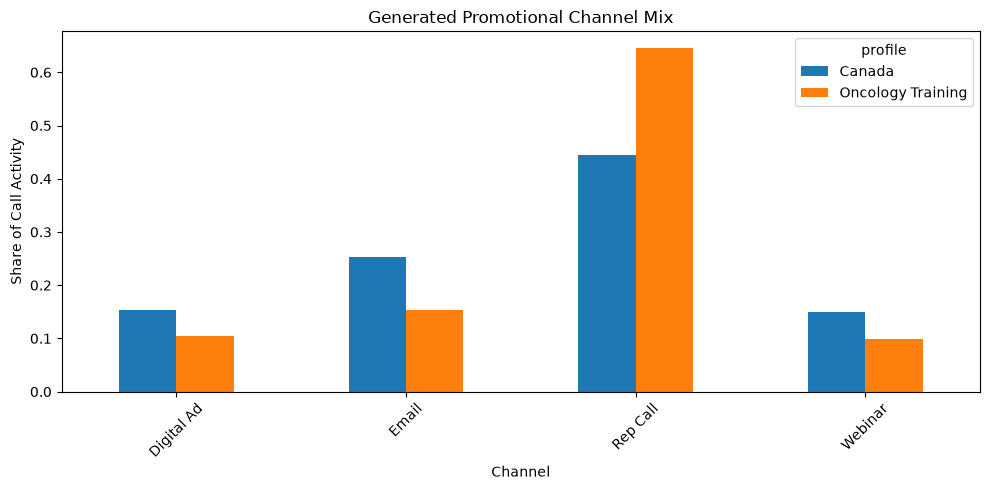

In [19]:
generated_channel_pivot = generated_channels.pivot(
    index="channel",
    columns="profile",
    values="generated_share",
).fillna(0)

generated_channel_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Generated Promotional Channel Mix")
plt.xlabel("Channel")
plt.ylabel("Share of Call Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The generated channel mix should broadly follow the profile configuration.

This means a learner can create different engagement environments without modifying the Python generator.

For example, a profile could represent:

- a field-force-heavy market
- a digital-first strategy
- a webinar-led educational campaign
- a balanced omnichannel environment

## Compare the Generated Product Portfolios

The product dataset shows how profile configuration becomes part of the generated analytical model.

In [20]:
def generated_product_summary(
    profile_name: str,
    datasets: dict,
) -> pd.DataFrame:
    product_frame = datasets["product"].copy()
    product_frame.insert(
        0,
        "profile",
        profile_name,
    )

    return product_frame


generated_products = pd.concat(
    [
        generated_product_summary(
            "Canada",
            canada,
        ),
        generated_product_summary(
            "Oncology Training",
            oncology,
        ),
    ],
    ignore_index=True,
)

generated_product_columns = [
    column
    for column in [
        "profile",
        "product_id",
        "product_name",
        "therapeutic_area",
        "manufacturer",
        "brand_type",
        "baseline_market_share",
    ]
    if column in generated_products.columns
]

generated_products[generated_product_columns]

,profile,product_id,product_name,therapeutic_area,manufacturer,brand_type,baseline_market_share
0,Canada,P001,CardioOne,Cardiology,NVA Pharma,Innovator,1.00
1,Canada,P002,NeuroMax,Neurology,NVA Pharma,Innovator,1.00
2,Canada,P003,EndoCare,Endocrinology,NVA Pharma,Innovator,1.00
3,Oncology Training,P001,OncoNova,Oncology,NVA Pharma,Innovator,0.45
4,Oncology Training,P002,Tumora,Oncology,Competitor A,Competitor,0.35
5,Oncology Training,P003,Immunex,Oncology,Competitor B,Competitor,0.20


## Compare Market Demand

Profiles may also contain different demand assumptions.

Market demand represents the total prescription opportunity available in each month.

Later notebooks examine demand in detail. Here, we only want to see whether the profiles produce different market environments.

In [21]:
def monthly_demand(
    profile_name: str,
    datasets: dict,
) -> pd.DataFrame:
    result = datasets["market_demand"][
        [
            "month",
            "market_nrx",
        ]
    ].copy()

    result["month"] = pd.to_datetime(
        result["month"]
    )
    result["profile"] = profile_name

    return result


demand_comparison = pd.concat(
    [
        monthly_demand(
            "Canada",
            canada,
        ),
        monthly_demand(
            "Oncology Training",
            oncology,
        ),
    ],
    ignore_index=True,
)

demand_comparison.head()

,month,market_nrx,profile
0,2023-01-01,1137,Canada
1,2023-02-01,1173,Canada
2,2023-03-01,1268,Canada
3,2023-04-01,1270,Canada
4,2023-05-01,1314,Canada


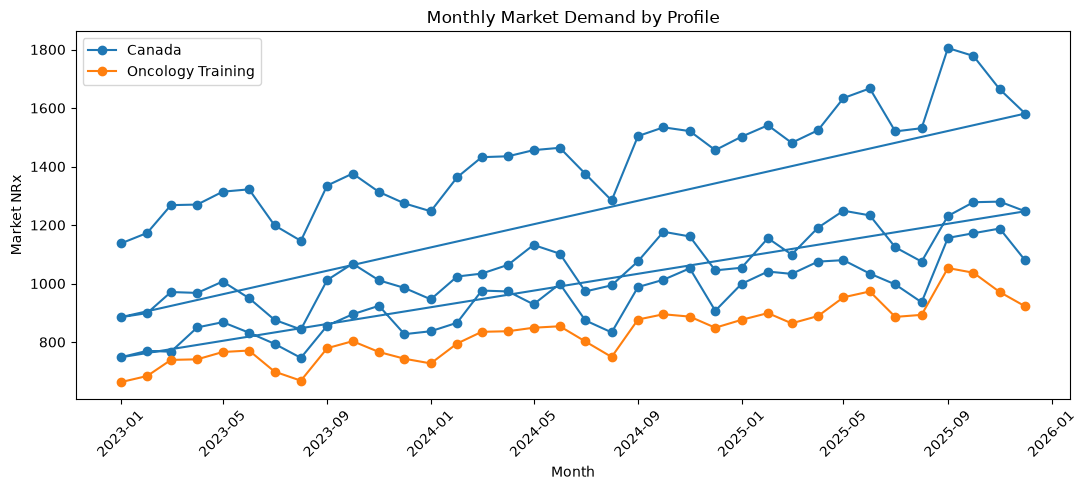

In [22]:
plt.figure(figsize=(11, 5))

for profile_name, profile_data in (
    demand_comparison.groupby("profile")
):
    plt.plot(
        profile_data["month"],
        profile_data["market_nrx"],
        marker="o",
        label=profile_name,
    )

plt.title("Monthly Market Demand by Profile")
plt.xlabel("Month")
plt.ylabel("Market NRx")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### A Profile Is More Than a Dataset Template

The two runs were produced by the same engine.

However, their configuration influenced:

- the market identity
- the product portfolio
- the HCP population
- the promotional channel mix
- the demand environment
- the resulting analytical datasets

This is what makes profiles useful for experimentation.

```text
Change the assumptions
        ↓
Rerun the simulation
        ↓
Observe the downstream effects
```

## What Should Be Configured, and What Should Be Code?

A useful design principle in HealthSynth is:

> Business assumptions belong in configuration. Simulation rules belong in code.

Examples of configuration:

- Canada versus another country
- oncology versus cardiology
- three products versus five products
- channel mix
- market growth rate
- launch date

Examples of simulation rules:

- how products become active
- how adoption is calculated
- how market share is normalized
- how prescriptions reconcile to market demand

This separation allows users to experiment without changing the implementation.

## Key Takeaways

Market profiles define the commercial world that HealthSynth simulates.

In this notebook, we learned that:

- the same engine can generate different markets
- YAML keeps business assumptions separate from Python code
- profiles can define markets, products, HCPs, channels, and demand
- configured distributions become generated populations through sampling
- generated values should reflect the profile without being identical in every run
- two datasets with similar row counts may still represent very different commercial environments

Profiles are the starting point for every HealthSynth scenario.

## Try It Yourself

### Experiment 1 — Increase Oncology Concentration

In a copy of the Canada profile, increase the configured Oncology specialty share.

Before rerunning, predict:

- How will the HCP population change?
- Will the total number of HCPs change?
- Which dataset will show the difference most clearly?

---

### Experiment 2 — Change the Channel Mix

Increase Email and reduce Rep Call activity.

Then compare:

```python
datasets["call_activity"]["channel"].value_counts(
    normalize=True
)
```

Does the generated mix move in the expected direction?

---

### Experiment 3 — Increase Market Demand

Change the profile's base monthly NRx.

Which outputs change?

Which master datasets remain unchanged?

---

### Experiment 4 — Change the Sample Size

Run the same profile with:

```python
hcps=100
```

and:

```python
hcps=5000
```

Which generated specialty distribution is closer to the configured values?

Make a prediction before running each experiment.

## What's Next?

In Notebook 03, we will focus on **Competitor Products**.

We will explore how products are represented in HealthSynth and how product-level assumptions shape the competitive market.

Notebook 02 showed us how to define the world.

Notebook 03 looks more closely at the products competing within it.